# Phase 2 Experiment: Preprocessing and Filtering

This notebook is a quick, executable tour of the integrated Phase 2 methods. It explains the production stages, demonstrates the real preprocessing controller on a tiny dataset, and interprets the completed production artifacts.

**It intentionally does not rerun the 1.7 million-record pipeline.** The complete run remains available through `verify/phase2/run_phase2.py`.

## Stage map

```text
Phase 1 aligned Twitter streams
    -> empirical user-activity audit
    -> high-volume user filtering
    -> exact tweet-text deduplication
    -> conservative text cleaning and validation
    -> twitter_cleaned.parquet
```

The sequence matters. Exact duplicates are identified before URLs and HTML are removed, preventing records that only become similar after cleaning from being silently collapsed.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src").is_dir() and (candidate / "output").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the project or notebooks directory.")


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


def read_json(relative_path: str):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))


print(f"Project root: {ROOT}")


Project root: d:\GW_UNIVERSITY\AIS\Social_Listener\Env\Social_Listener_V1\UOG_AIS_SOCIAL_LISTENER


## 1. Confirm the production artifacts

The manifest is the compact audit record for the completed run. Reading it is much faster than loading both Phase 1 Twitter Parquet files.

In [2]:
phase2_manifest = read_json("output/results/phase2/preprocessing_manifest.json")
artifact_paths = [
    "data/02_interim/twitter_cleaned.parquet",
    "output/results/phase2/preprocessing_manifest.json",
    "output/results/phase2/user_activity_threshold_audit.json",
    "output/reports/phase2/preprocessing_report.md",
]
pd.DataFrame(
    [{"artifact": path, "exists": (ROOT / path).exists()} for path in artifact_paths]
)

,artifact,exists
0,data/02_interim/twitter_cleaned.parquet,True
1,output/results/phase2/preprocessing_manifest.json,True
2,output/results/phase2/user_activity_threshold_...,True
3,output/reports/phase2/preprocessing_report.md,True


## 2. User-activity audit and threshold selection

The activity metric is:

`tweets_per_active_day = total tweets / days on which the user posted`

Several empirical tail thresholds are compared. The selected threshold is not a claim that removed users are bots; it limits the influence of unusually high-volume accounts.

In [3]:
audit = phase2_manifest["user_activity_audit"]
tradeoffs = pd.DataFrame(audit["tradeoffs"]).sort_values("threshold")
display(Markdown(
    f"**Selected threshold:** `{audit['selected_threshold']:.1f}` tweets per active day  \n"
    f"**Decision:** {audit['selection_reason']}"
))
display(Markdown(
    "**Maximum users removed:** 1%  \n"
    "**Maximum tweets removed:** 10%"
))
tradeoffs[[
    "method", "threshold", "users_removed", "users_removed_pct",
    "tweets_removed", "tweets_removed_pct"
]].style.format({
    "threshold": "{:.3f}",
    "users_removed": "{:,.0f}",
    "users_removed_pct": "{:.2f}%",
    "tweets_removed": "{:,.0f}",
    "tweets_removed_pct": "{:.2f}%",
})

**Selected threshold:** `9.0` tweets per active day  
**Decision:** No candidate at or above P99 met both retention safeguards; selected P99.5 because it has the smallest combined safeguard exceedance among eligible tail thresholds.

**Maximum users removed:** 1%  
**Maximum tweets removed:** 10%

,method,threshold,users_removed,users_removed_pct,tweets_removed,tweets_removed_pct
7,mad_threshold,1.000,"159,599",33.03%,"1,354,893",77.53%
4,iqr_upper_fence,2.667,"30,928",6.40%,"730,824",41.82%
0,p95,3.000,"19,558",4.05%,"636,787",36.44%
5,extreme_iqr_upper_fence,3.667,"15,838",3.28%,"550,319",31.49%
1,p97_5,4.000,"10,218",2.11%,"491,261",28.11%
6,log_z_threshold,4.550,"8,904",1.84%,"445,847",25.51%
2,p99,6.000,"4,610",0.95%,"332,815",19.04%
3,p99_5,9.000,"2,227",0.46%,"222,366",12.72%


### Result discussion

The chosen P99.5 threshold removes only **0.46% of users**, but those users produced **12.72% of tweets**. This confirms that a small high-volume group could strongly affect downstream sentiment aggregates. The P99 option would remove fewer than 1% of users but over 19% of tweets, so the more permissive threshold of 9 is the documented compromise.

## 3. Demonstrate the integrated preprocessing controller with real records

This experiment extracts representative records from the actual aligned Phase 1
Twitter Parquet files. It includes at least five real effects:

- all 439 records from a genuinely high-volume user are supplied so the approved
  activity rule can evaluate the user's real posting rate;
- a real exact duplicate appearing in both candidate streams shows
  first-observation retention;
- a real URL-bearing tweet shows URL removal;
- a real HTML-encoded tweet shows entity decoding;
- a real invalid-Unicode tweet shows text-validation rejection;
- a real tweet with capitalization, punctuation, and emoji shows preservation of
  sentiment cues.

Only these selected records are loaded, so this remains a quick experiment rather
than a full Phase 2 rerun.

In [4]:
from src.phase2_preprocessing.cleaning_heuristics_model import CleaningPolicy
from src.phase2_preprocessing.preprocessing_runner_controller import PreprocessingRunnerController
from src.phase2_preprocessing.telemetry_reporter_view import TelemetryReporterView
import pyarrow.dataset as ds

# IDs were selected from the actual Phase 1 aligned Twitter outputs to represent
# distinct production behaviors. The records themselves are always read from Parquet.
case_specs = pd.DataFrame([
    {"case": "Exact duplicate: Joe Biden stream", "id": "1.3233036222186742e+18", "candidate": "joe_biden"},
    {"case": "Exact duplicate: Donald Trump stream", "id": "1.3233036222186742e+18", "candidate": "donald_trump"},
    {"case": "URL removal", "id": "1.316529221557252e+18", "candidate": "donald_trump"},
    {"case": "HTML entity decoding", "id": "1.3165295949089055e+18", "candidate": "donald_trump"},
    {"case": "Invalid Unicode rejection", "id": "1.3171495641687e+18", "candidate": "donald_trump"},
    {"case": "Preserve capitals, punctuation, and emoji", "id": "1.316529289949569e+18", "candidate": "donald_trump"},
])
high_volume_user_id = "1.30577286362291e+18"
source_paths = [
    ROOT / "data/02_interim/twitter_donald_trump.parquet",
    ROOT / "data/02_interim/twitter_joe_biden.parquet",
]
source = ds.dataset([str(path) for path in source_paths], format="parquet")
selected_ids = case_specs["id"].unique().tolist()
filter_expression = (
    ds.field("id").isin(selected_ids)
    | (ds.field("user_id") == high_volume_user_id)
)
actual_cases = source.to_table(filter=filter_expression).to_pandas()
actual_cases = actual_cases.merge(case_specs, on=["id", "candidate"], how="left")
actual_cases = actual_cases.loc[
    actual_cases["case"].notna() | actual_cases["user_id"].eq(high_volume_user_id)
].copy()
actual_cases["case"] = actual_cases["case"].fillna("High-volume user removal")
actual_cases["case_row_key"] = range(len(actual_cases))

reporter = TelemetryReporterView()
policy = CleaningPolicy(
    maximum_tweets_per_active_day=phase2_manifest["policy"]["maximum_tweets_per_active_day"]
)
cleaned_cases = PreprocessingRunnerController(reporter, policy).execute_dataframe(actual_cases)

comparison = actual_cases[["case_row_key", "case", "user_id", "date", "tweet"]].merge(
    cleaned_cases[["case_row_key", "tweet"]].rename(columns={"tweet": "cleaned_tweet"}),
    on="case_row_key",
    how="left",
)
comparison["outcome"] = comparison["cleaned_tweet"].notna().map(
    {True: "retained", False: "removed"}
)
comparison["changed_by_cleaning"] = (
    comparison["cleaned_tweet"].notna()
    & comparison["tweet"].ne(comparison["cleaned_tweet"])
)

# Show one high-volume row plus every other selected real case.
case_preview = pd.concat([
    comparison.loc[comparison["case"].eq("High-volume user removal")].head(1),
    comparison.loc[~comparison["case"].eq("High-volume user removal")],
], ignore_index=True)
display(case_preview[[
    "case", "user_id", "outcome", "changed_by_cleaning", "tweet", "cleaned_tweet"
]])

display(Markdown("**Actual-case stage telemetry**"))
display(pd.DataFrame(reporter.stage_metrics).T)

display(Markdown("**High-volume user's real activity evidence**"))
user_metrics = pd.read_parquet(ROOT / "output/results/phase2/user_activity_metrics.parquet")
user_metrics.loc[
    user_metrics["user_id"].astype("string").eq(high_volume_user_id),
    ["user_id", "total_tweets", "active_days", "tweets_per_active_day", "max_tweets_single_day"],
]

,case,user_id,outcome,changed_by_cleaning,tweet,cleaned_tweet
0,High-volume user removal,1.30577286362291e+18,removed,False,#wilders #PVV #🇳🇱 #🧡 #vangogh #theo #theovang...,NaN
1,URL removal,360666534.0,retained,True,#Elecciones2020 | En #Florida: #JoeBiden dice ...,#Elecciones2020 | En #Florida: #JoeBiden dice ...
2,"Preserve capitals, punctuation, and emoji",7.674018410302095e+17,retained,False,@richardmarx Glad u got out of the house! DICK...,@richardmarx Glad u got out of the house! DICK...
3,HTML entity decoding,36024393.0,retained,True,@karatblood @KazePlays_JC Grab @realDonaldTrum...,@karatblood @KazePlays_JC Grab @realDonaldTrum...
4,Invalid Unicode rejection,237686935.0,removed,False,President Trump is Allocating $14.7 Billion To...,NaN
5,Exact duplicate: Donald Trump stream,2234574072.0,retained,True,!\nhttps://t.co/j0pcz91CSs\n!\nWhat will be ha...,! ! What will be happened next. Who will be th...
6,Exact duplicate: Joe Biden stream,2234574072.0,removed,False,!\nhttps://t.co/j0pcz91CSs\n!\nWhat will be ha...,NaN


**Actual-case stage telemetry**

,initial_count,final_count,dropped_count,drop_rate_pct
bot_filter,445.0,6.0,439.0,98.651685
exact_duplicate_filter,6.0,5.0,1.0,16.666667
text_cleaning,5.0,4.0,1.0,20.000000


**High-volume user's real activity evidence**

,user_id,total_tweets,active_days,tweets_per_active_day,max_tweets_single_day
121142,1.30577286362291e+18,439,2,219.5,438


### What the real-data experiment shows

- The selected high-volume user produced **439 tweets over 2 active days**, or
  **219.5 tweets per active day**, so all of that user's records are rejected by
  the approved threshold of 9.
- The same exact tweet appears in both candidate streams. The first observed record
  is retained and the later duplicate is removed.
- URLs are removed and HTML entities such as `&amp;` are decoded without flattening
  the remaining text.
- The record containing the Unicode replacement character is rejected during text
  validation.
- Capitalization, repeated punctuation, and emoji remain intact for downstream
  VADER scoring.

These are genuine source records, but they are deliberately selected examples. The
production manifest later in the notebook gives the complete-dataset effect sizes.

## 4. Production stage results

In [5]:
stage_results = (
    pd.DataFrame(phase2_manifest["stage_metrics"])
    .T.rename_axis("stage")
    .reset_index()
)
stage_results.style.format({
    "initial_count": "{:,.0f}",
    "final_count": "{:,.0f}",
    "dropped_count": "{:,.0f}",
    "drop_rate_pct": "{:.3f}%",
})

,stage,initial_count,final_count,dropped_count,drop_rate_pct
0,bot_filter,"1,747,542","1,525,176","222,366",12.725%
1,exact_duplicate_filter,"1,525,176","1,331,345","193,831",12.709%
2,text_cleaning,"1,331,345","1,331,317",28,0.002%


In [6]:
from pyarrow.parquet import ParquetFile

cleaned_path = ROOT / "data/02_interim/twitter_cleaned.parquet"
parquet = ParquetFile(cleaned_path)
pd.Series({
    "rows": parquet.metadata.num_rows,
    "columns": parquet.metadata.num_columns,
    "row_groups": parquet.metadata.num_row_groups,
    "retention_rate_pct": phase2_manifest["retention_rate_pct"],
}, name="production_output")

rows                  1.331317e+06
columns               9.000000e+00
row_groups            2.000000e+00
retention_rate_pct    7.618226e+01
Name: production_output, dtype: float64

### Production result discussion

- Phase 2 retained **1,331,317 of 1,747,542 records (76.18%)**.
- High-volume filtering removed **222,366 records**.
- Exact-text deduplication removed another **193,831 records**.
- Only **28 records** failed after text cleaning, showing that the cleaner is intentionally conservative.
- Account-age filtering was unavailable because Phase 1 does not contain `user_created_at`; the pipeline records this limitation instead of inferring the field.

## 5. Existing research figures

**activity_distribution_with_thresholds.png**

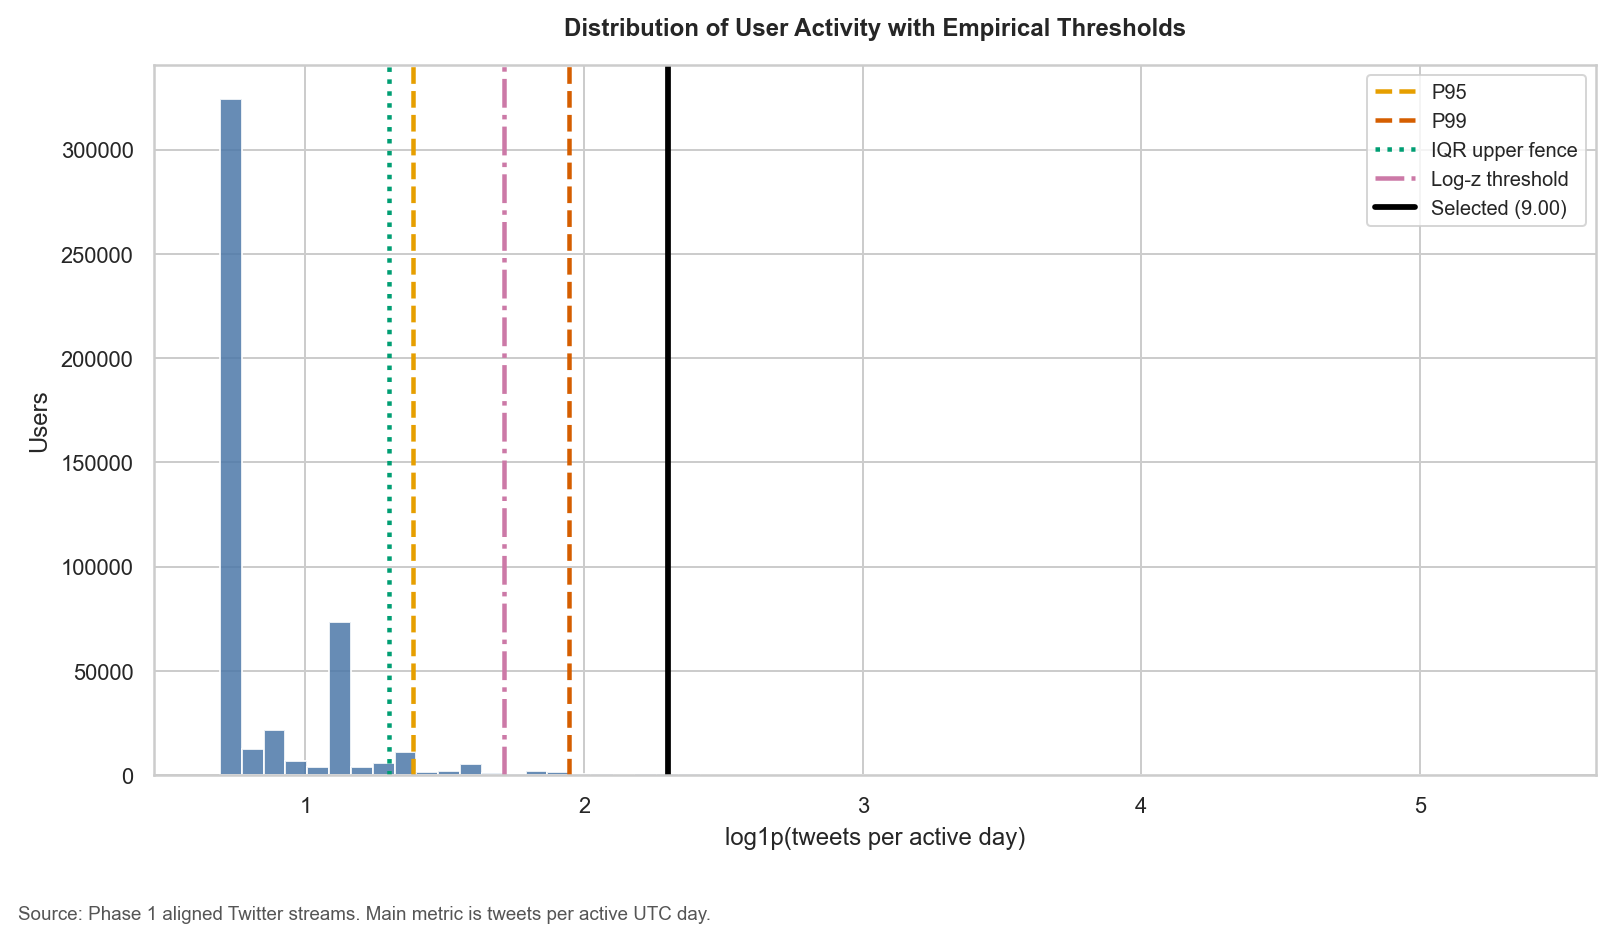

**filtering_tradeoff_users_vs_tweets.png**

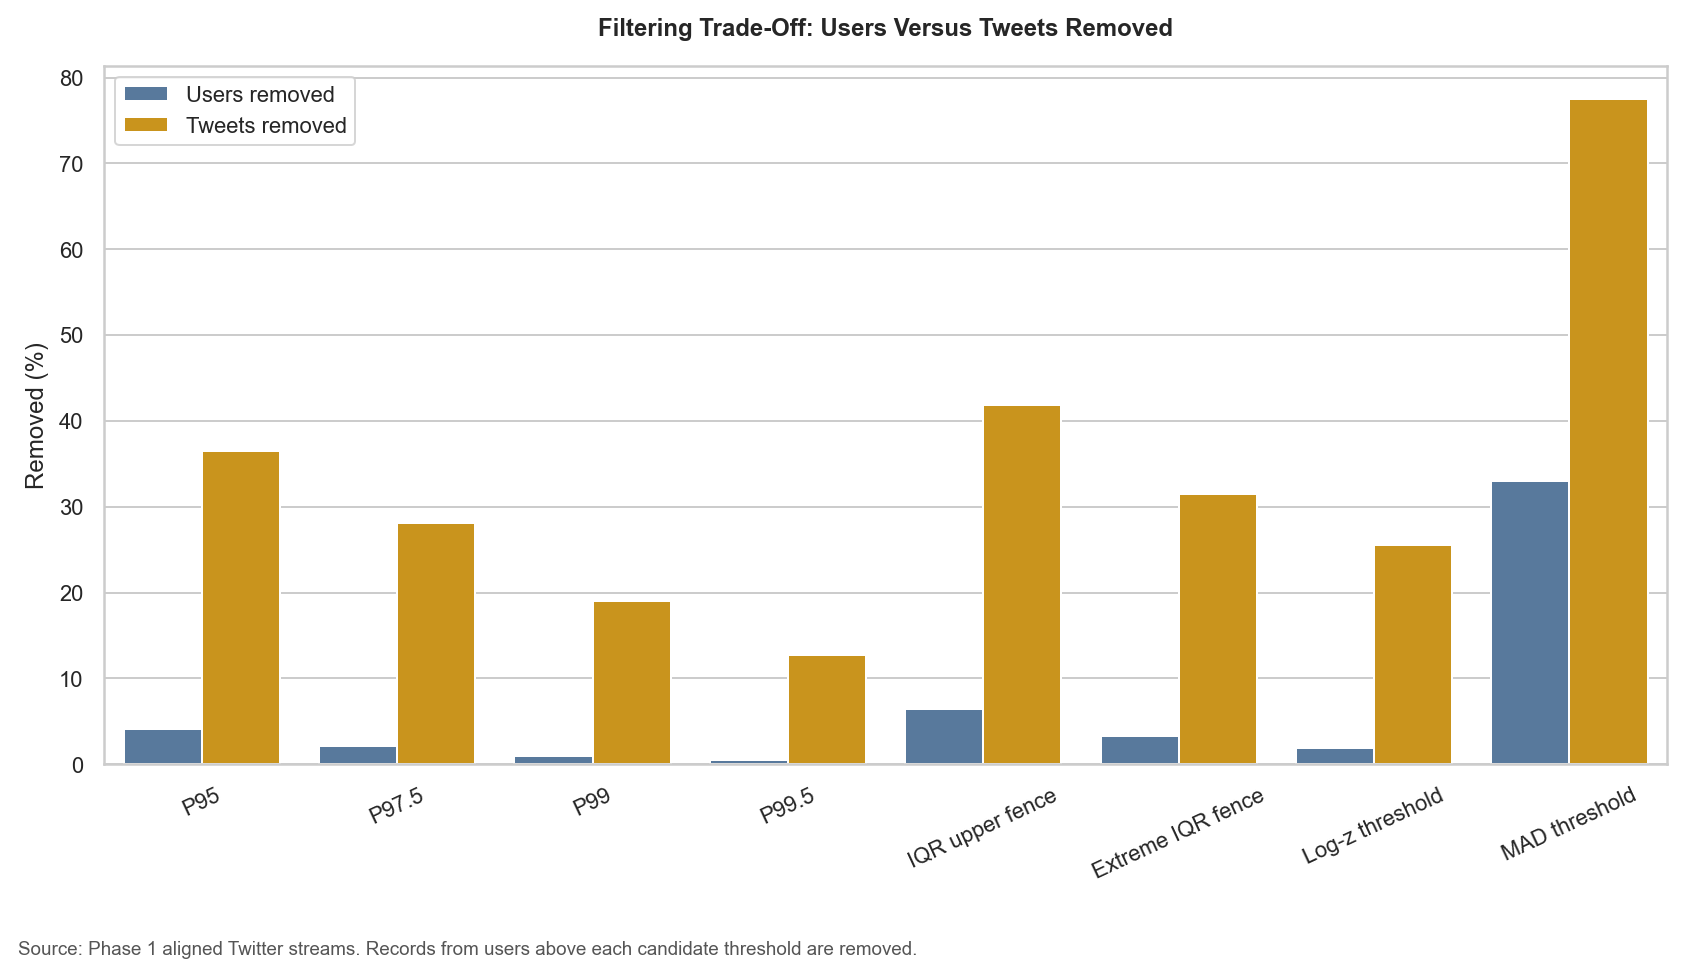

**daily_volume_before_after_filtering.png**

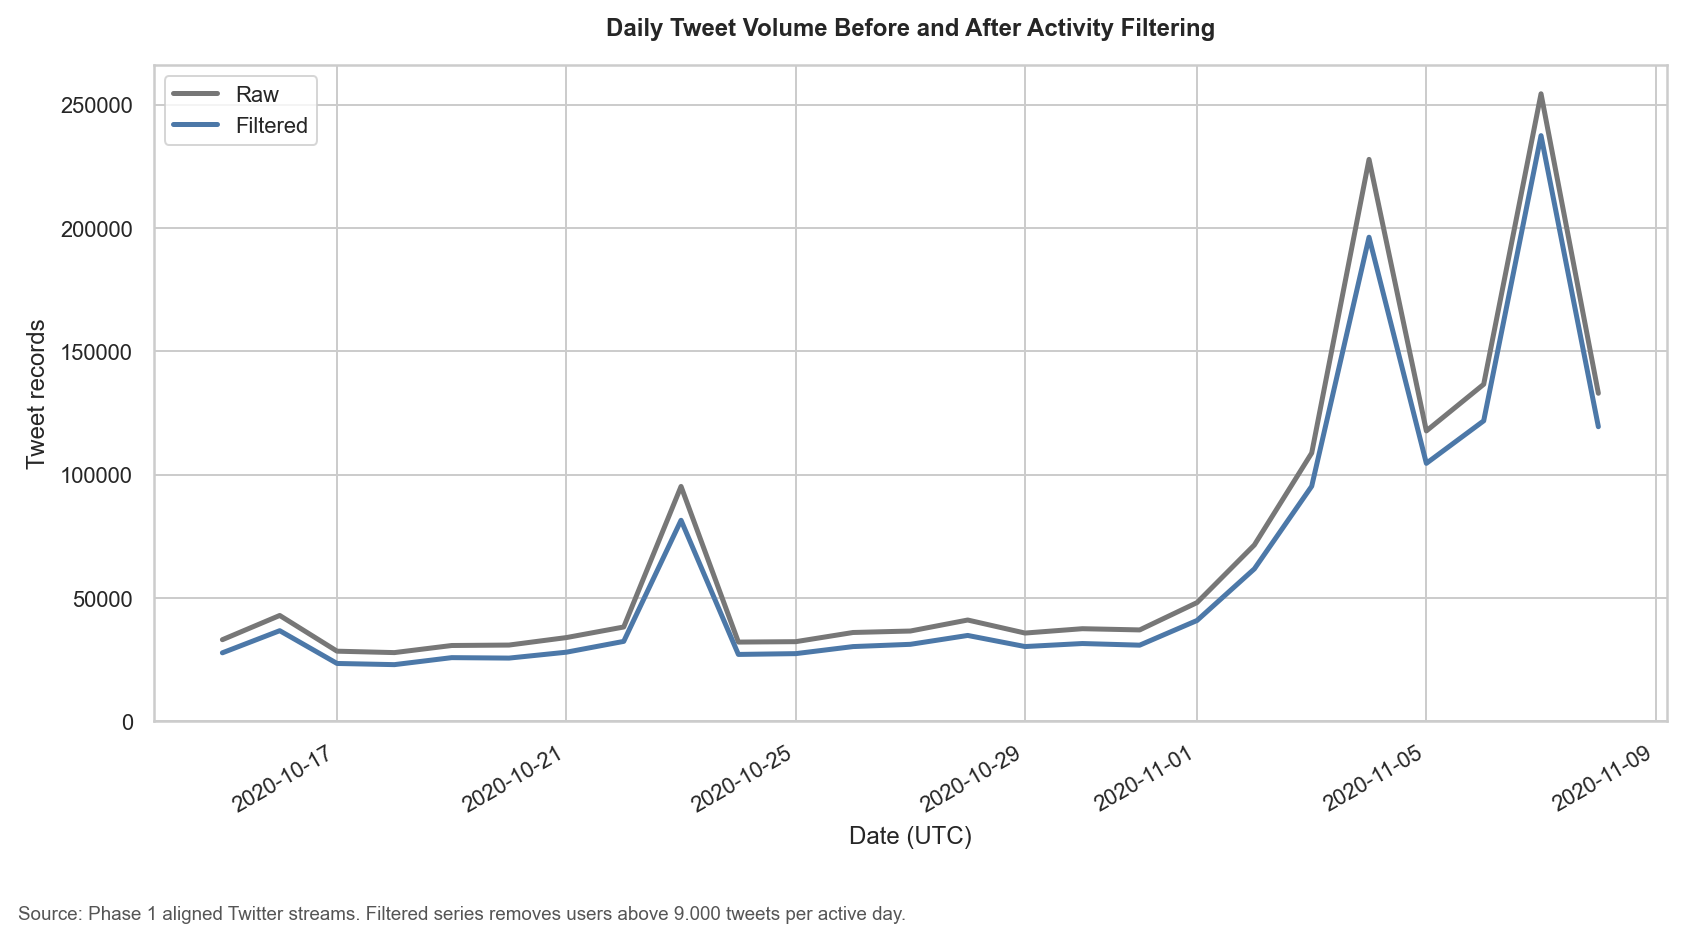

In [7]:
for relative_path in [
    "output/graphs/phase2/activity_distribution_with_thresholds.png",
    "output/graphs/phase2/filtering_tradeoff_users_vs_tweets.png",
    "output/graphs/phase2/daily_volume_before_after_filtering.png",
]:
    display(Markdown(f"**{Path(relative_path).name}**"))
    display(Image(filename=str(ROOT / relative_path)))

## Takeaway

Phase 2 integrates an empirical activity audit with deterministic filtering and conservative cleaning. Its main analytical effect is not aggressive text normalization; it is reducing disproportionate high-volume and repeated content while preserving sentiment cues for Phase 3.